# 01 — Derivative, Gradient, Chain Rule (demo)

Minh hoạ trực quan đạo hàm là *độ nhạy*, và Chain Rule là cách "truyền độ nhạy" qua nhiều bước biến đổi — nền tảng của toàn bộ Backpropagation. Xem `docs/phase2_math_content.md` mục 2.1–2.4 để đối chiếu công thức đầy đủ.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys; sys.path.insert(0, '..')


## Đạo hàm là độ nhạy: $y=x^2 \Rightarrow dy/dx=2x$

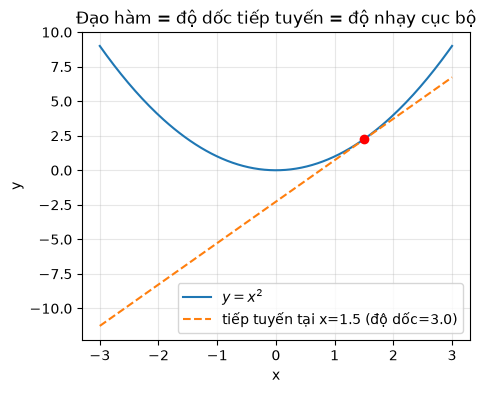

Tại x=1.5: dy/dx = 2x = 3.0


In [2]:
x = np.linspace(-3, 3, 200)
y = x**2
x0 = 1.5
slope = 2*x0
tangent = y[np.argmin(np.abs(x-x0))] + slope*(x-x0)
fig, ax = plt.subplots(figsize=(5,4))
ax.plot(x, y, label='$y=x^2$')
ax.plot(x, tangent, '--', label=f'tiếp tuyến tại x={x0} (độ dốc={slope})')
ax.scatter([x0],[x0**2], color='red', zorder=5)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend(); ax.grid(alpha=.3)
ax.set_title('Đạo hàm = độ dốc tiếp tuyến = độ nhạy cục bộ')
plt.show()
print(f'Tại x={x0}: dy/dx = 2x = {slope}')

## Chain Rule trên đồ thị $x \to z=wx+b \to a=\mathrm{ReLU}(z) \to L$

Dùng đúng số liệu đã verify trong `experiments/toy_example_verify.py` (không tính tay lại).

In [3]:
from experiments.toy_example_verify import relu, relu_grad

x, w, b, y_target = 2.0, 0.5, -0.3, 1.0
z = w*x + b
a = relu(z)
L = 0.5*(a-y_target)**2
dL_da = a - y_target
da_dz = relu_grad(np.array(z)).item()
dL_dz = dL_da*da_dz
dL_dw = dL_dz*x
dL_db = dL_dz*1.0
dL_dx = dL_dz*w
print(f'forward:  z={z:.4f} a={a:.4f} L={L:.6f}')
print(f'backward: dL/dw={dL_dw:.4f}  dL/db={dL_db:.4f}  dL/dx={dL_dx:.4f}')

forward:  z=0.7000 a=0.7000 L=0.045000
backward: dL/dw=-0.6000  dL/db=-0.3000  dL/dx=-0.1500


**Kết luận**: mỗi bước chỉ cần đạo hàm cục bộ của chính nó ($\partial a/\partial z$, $\partial z/\partial w$, ...); Chain Rule nhân dồn chúng lại — đây chính là cơ chế mà Mục 4 (Backprop) tổng quát hoá cho mạng nhiều lớp.